 # Artificial Intelligence Technology and Application

 ## Machine Learning Lab Guide - Student Version

 # 1 E-commerce Website User Group Analysis

 ## 1.1 Introduction

 This experiment performs modeling based on the K-means algorithm by using the virtual dataset automatically generated by sklearn to obtain user categories.

 ## 1.2 Experiment Code

 ### 1.2.1 Using sklearn for Modeling

 **Step 1: Import libraries.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


 **Step 2: Create a dataset.**

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, centers=2, n_features=2, random_state=3)

# Display dataset shape
print(f"Data shape: {X.shape}")


Data shape: (2000, 2)


 **Step 3: Apply the K-means algorithm.**

In [3]:
from sklearn.cluster import KMeans

kmeans_model = KMeans(n_clusters=5, random_state=42)
y_pred = kmeans_model.fit_predict(X)


 **Step 4: Visualize the output.**

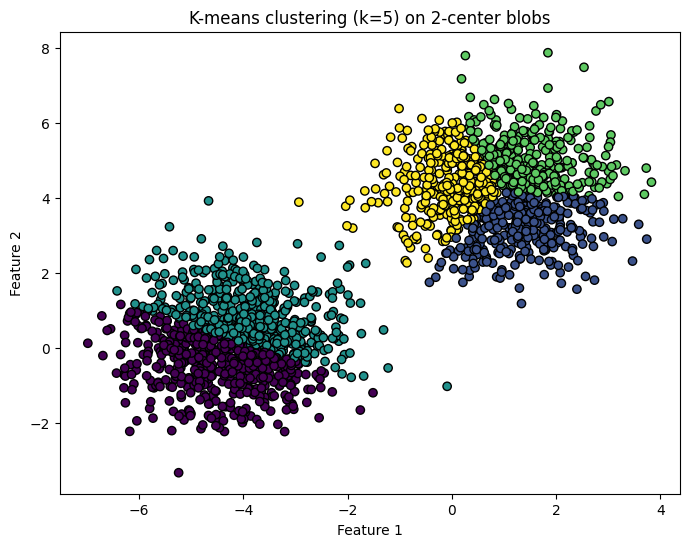

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', marker='o', edgecolor='k')
plt.title("K-means clustering (k=5) on 2-center blobs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


 **Step 5: Use more features for comparison.**

In [5]:
X_10, y_10 = make_blobs(n_samples=2000, centers=3, n_features=10, random_state=30)

print(f"New dataset shape with 10 features: {X_10.shape}")


New dataset shape with 10 features: (2000, 10)


 ### 1.2.2 Selecting the Optimal k Value

 Find the optimal 'k' value by iterating over multiple possible values and plotting the 'inertia' attribute (the Elbow Method).

 We randomly generate data with e.g. 21 centers and use the elbow method to spot the turning point.

Generated hidden centers: 21


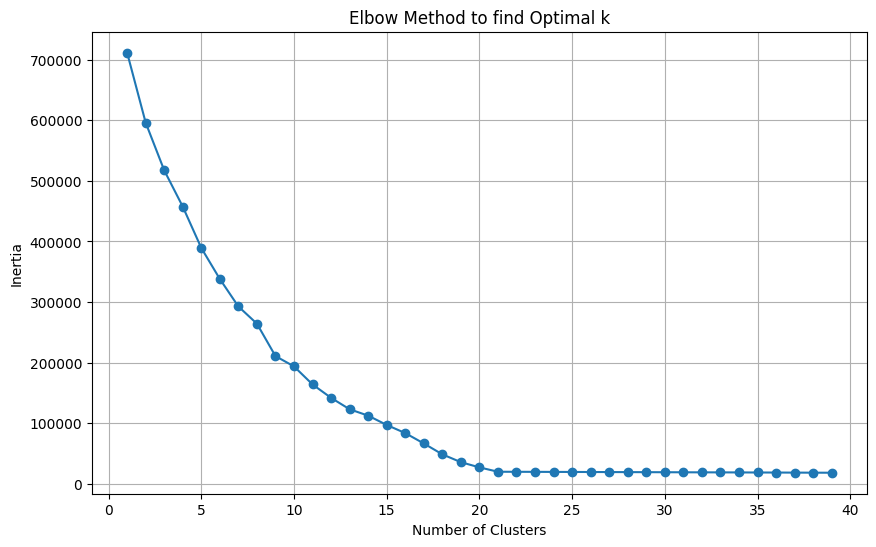

In [6]:
# Setting centers randomly between 1 and 30
np.random.seed(42)
n_centers = np.random.randint(15, 25) # Let's say it turns out to be around 21

X_opt, y_opt = make_blobs(n_samples=2000, centers=n_centers, n_features=10, random_state=42)
print(f"Generated hidden centers: {n_centers}")

inertias = []
k_range = range(1, 40)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_opt)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o')
plt.title("Elbow Method to find Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(np.arange(0, 41, step=5))
plt.grid(True)
plt.show()

# The turning point on the plot corresponds to the optimal k value.
